In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\ADMIN\OneDrive\Documents\new_Influencer_Campaign_Dataset.csv")
print(df.head())
print(df.tail())
print(df.columns.tolist())
print(df.info())
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
campaign_metrics=['Impressions','Clicks','Conversions','Likes','Shares','Comments','Revenue','Campaign_Spend','Reach']
print(df[campaign_metrics].describe())
df['Engagement']=df['Likes']+df['Comments']+df['Shares']
df['Engagement_rate']=(df['Engagement']/df['Reach'])*100
df['Conversion_rate']=(df['Conversions']/df['Clicks'])*100
df['ROI']=((df['Revenue']-df['Campaign_Spend'])/df['Campaign_Spend'])*100
df['Cost_per_engagement']=df['Campaign_Spend']/df['Engagement']
print(df.head())
df.to_csv("Influencer_Campaign_Cleaned.csv",index=False)

  Campaign_ID    Campaign_Name Influencer_ID Influencer_Name   Platform  \
0   CMP000001       Flash Sale        INF029           Priya   snapchat   
1   CMP000002  Brand Awareness        INF047           Arjun    Twitter   
2   CMP000003       New Launch        INF050           Rahul    YouTube   
3   CMP000004  Brand Awareness        INF022            Riya  Instagram   
4   CMP000005  Brand Awareness        INF036            Riya  Instagram   

  Category  Followers Audience_Group  Gender Campaign_Date  ...  \
0  Fitness     832594          18-24    Male    01-01-2025  ...   
1   Beauty     867573            45+    Male    02-01-2025  ...   
2     Food     773212          18-24   Mixed    03-01-2025  ...   
3     Food     116855          25-34    Male    04-01-2025  ...   
4     Food    1081144            45+  Female    05-01-2025  ...   

   Campaign_Spend  Engagement  Revenue  Engagement_Rate  Conversion_Rate  \
0          135576       51767  4813180            10.69            19.

In [2]:
print("\n---phase2---")
total_campaigns = df["Campaign_ID"].nunique()
print("\nTotal Campaigns :",total_campaigns)

total_reach = df["Reach"].sum()
print("Total Reach :",total_reach)

total_spend = df["Campaign_Spend"].sum()
print("Total Campaign Spend :",total_spend)

total_revenue = df["Revenue"].sum()
print("Total Revenue :",total_revenue)

avg_engagement_rate = df["Engagement_Rate"].mean()
print("Average Engagement Rate : {:2f}%".format(avg_engagement_rate))

avg_conversion_rate = df["Conversion_Rate"].mean()
print("Average Conversion Rate :{:.2f}%".format(avg_conversion_rate))

avg_roi = df["ROI"].mean()
print("Average ROI :{:.2f}%".format(avg_roi))

avg_cpe = df["Cost_Per_Engagement"].mean()
print("Average Cost Per Engagement :{:.2f}".format(avg_cpe))


---phase2---

Total Campaigns : 1000000
Total Reach : 575918914068
Total Campaign Spend : 180288842927
Total Revenue : 6497142588922
Average Engagement Rate : 10.707802%
Average Conversion Rate :20.00%
Average ROI :3325.20%
Average Cost Per Engagement :4.26



---phase 3---


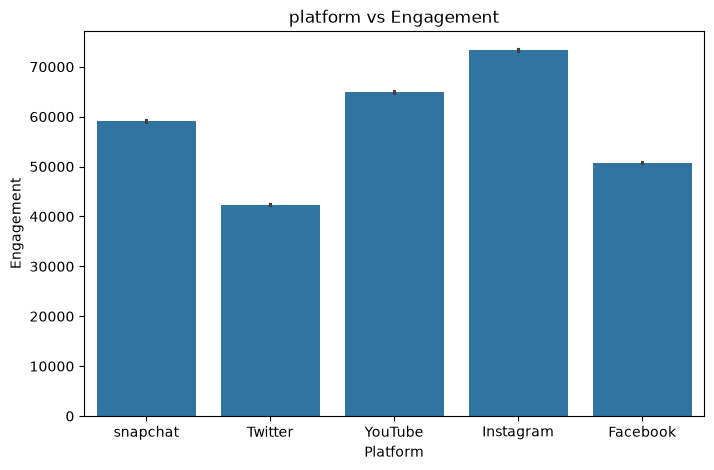

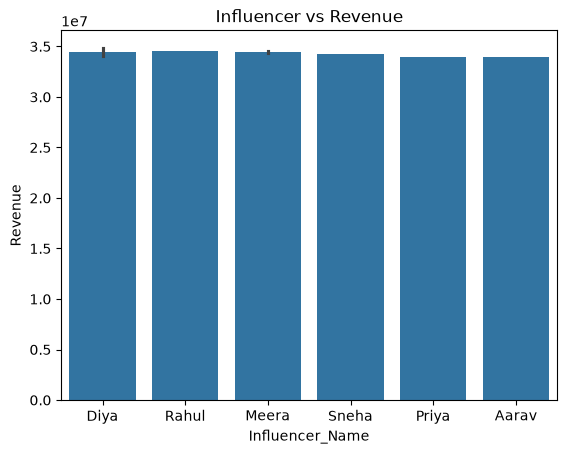

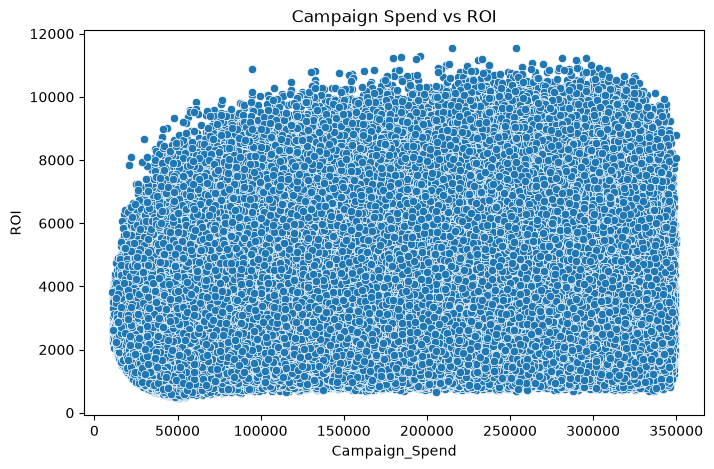

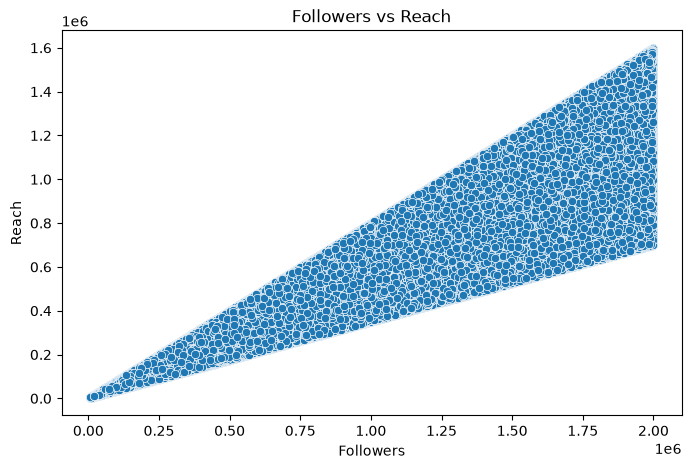

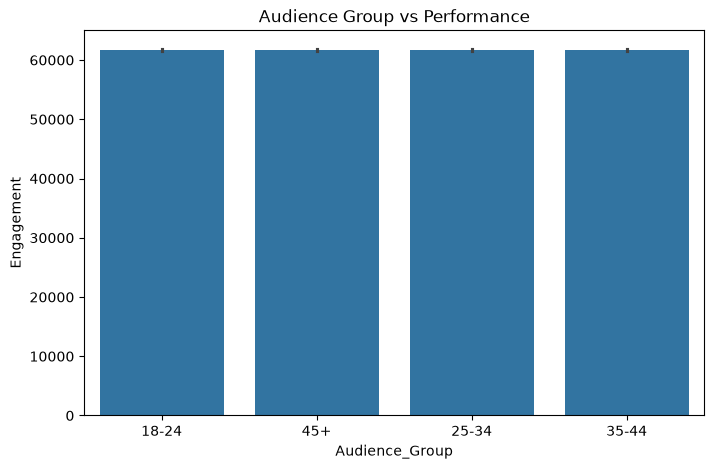

In [3]:
print("\n---phase 3---")
plt.figure(figsize=(8,5))
sns.barplot(x="Platform",y="Engagement",data=df)
plt.title("platform vs Engagement")
plt.show()

top10=df.nlargest(10,"Revenue")
sns.barplot(x="Influencer_Name", y="Revenue",data=top10)
plt.title("Influencer vs Revenue")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Campaign_Spend", y="ROI", data=df)
plt.title("Campaign Spend vs ROI")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Followers", y="Reach", data=df)
plt.title("Followers vs Reach")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="Audience_Group", y="Engagement",data=df)
plt.title("Audience Group vs Performance")
plt.show()

In [4]:
print("\n----PHASE 4----")

df["Segment"] = "Other"

df.loc[df["ROI"] >= 100, "Segment"] = "High ROI Influencers"

df.loc[df["Followers"] < 100000, "Segment"] = "Micro Influencers"

df.loc[df["Followers"] >= 1000000, "Segment"] = "Mega Influencers"

df.loc[df["Engagement_Rate"] >= 10, "Segment"] = "High Engagement Creators"

average_cost = df["Cost_Per_Engagement"].mean()

df.loc[df["Cost_Per_Engagement"] < average_cost,
       "Segment"] = "Cost Efficient Influencers"

print(df[["Influencer_Name",
          "Followers",
          "ROI",
          "Engagement_Rate",
          "Cost_Per_Engagement",
          "Segment"]].head())


----PHASE 4----
  Influencer_Name  Followers          ROI  Engagement_Rate  \
0           Priya     832594  3450.171122            10.69   
1           Arjun     867573  5343.043782             7.67   
2           Rahul     773212  2808.938174            10.66   
3            Riya     116855  2276.887543            12.59   
4            Riya    1081144  3068.966427            13.12   

   Cost_Per_Engagement                     Segment  
0                 2.62  Cost Efficient Influencers  
1                 5.06        High ROI Influencers  
2                 2.99  Cost Efficient Influencers  
3                 5.25    High Engagement Creators  
4                 2.80  Cost Efficient Influencers  
